# Grammar Scoring Engine — SHL Hiring Assessment
A reproducible speech → transcript → linguistic/transformer features → regression pipeline.

## 1. Competition Overview
Predict continuous grammatical proficiency in [0, 5]. Only the provided labeled recordings are training data; downloaded pretrained models are allowed. Test label-like fields are never used. RMSE is the primary selection criterion, with Pearson as a secondary criterion.

**Dataset integrity finding:** the official sample template contains 204 IDs, while test.csv and Kaggle’s upload dialog require 216 predictions. The default export follows the verified test.csv IDs and order. The mismatch is documented in the report.

**Execution:** run all cells. First execution downloads pretrained model weights and can take hours on CPU. FAST_MODE reduces inference and tree costs but still uses every recording. FULL mode increases ASR/embedding quality; it is not claimed to win without validation. Outputs are real computations, never invented metrics. Cached artifacts are keyed by audio content and inference settings.

**Update:** See [grammar_scoring_improvements.ipynb](grammar_scoring_improvements.ipynb) for the subsequent Wav2Vec2/acoustic ensemble and its improved validation results. The results below describe the original baseline.


**Public repository edition:** raw recordings, transcripts, row-level training labels, and their notebook outputs are omitted. Aggregate evaluation outputs are retained. The full pipeline was executed locally; the measured report below is copied from its generated artifact. Rerunning all cells with authorized competition data regenerates the complete analysis.


## 2. Imports & Configuration
Optional dependency installation: enable only in a trusted online environment. For offline Kaggle, attach pretrained model directories and install pre-downloaded wheels; model names below also accept local paths. Pretrained weights are the only external assets used.

In [1]:
INSTALL_DEPENDENCIES = False
if INSTALL_DEPENDENCIES:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "soundfile", "librosa", "faster-whisper", "sentence-transformers", "tqdm", "joblib"])
# Optional: pip install spacy catboost lightgbm xgboost language-tool-python
# Optional pretrained parser: python -m spacy download en_core_web_sm
# LanguageTool additionally requires a compatible Java runtime and a local distribution.

In [2]:
import os, sys, re, json, math, random, hashlib, gc, warnings, platform, importlib, time
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
from scipy.stats import pearsonr
from scipy.signal import resample_poly
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, StratifiedGroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.auto import tqdm
from IPython.display import display, Markdown, Audio
import joblib
import torch

FAST_MODE = os.environ.get("GRAMMAR_FAST", "1") == "1"
SEED = 42
N_FOLDS = 5
TARGET_MIN, TARGET_MAX = 0.0, 5.0
AUDIO_SAMPLE_RATE = 16000
ASR_MODEL = os.environ.get("GRAMMAR_ASR_MODEL", "base.en" if FAST_MODE else "medium.en")
TEXT_EMBEDDING_MODEL = os.environ.get("GRAMMAR_EMBEDDING_MODEL", "sentence-transformers/all-MiniLM-L6-v2" if FAST_MODE else "sentence-transformers/all-mpnet-base-v2")
USE_AUDIO_FEATURES = True
USE_LINGUISTIC_FEATURES = True
USE_PCA = True
USE_GRAMMAR_CHECKER = False
FORCE_RECOMPUTE_TRANSCRIPTS = False
FORCE_RECOMPUTE_EMBEDDINGS = False
DATA_ROOT = os.environ.get("GRAMMAR_DATA_ROOT")  # optional disambiguation, discovery otherwise
OUTPUT_DIR = Path(os.environ.get("GRAMMAR_OUTPUT_DIR", "artifacts"))
CACHE_DIR = Path(os.environ.get("GRAMMAR_CACHE_DIR", "cache"))
SUBMISSION_POLICY = os.environ.get("GRAMMAR_SUBMISSION_POLICY", "test_order")
ASR_WORKERS = 2 if not torch.cuda.is_available() else 1
ASR_CPU_THREADS = 2
MAX_ASR_FAILURE_FRACTION = 0.05
RUN_CALIBRATION = True
for p in (OUTPUT_DIR, CACHE_DIR): p.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # faster-whisper uses CPU on Apple Silicon
print({"platform": platform.platform(), "device": DEVICE, "FAST_MODE": FAST_MODE,
       "ASR": ASR_MODEL, "embedding": TEXT_EMBEDDING_MODEL})

## 3. Reproducibility

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)
torch.set_num_threads(min(8, os.cpu_count() or 1))
# PYTHONHASHSEED must be set before Python starts; no algorithm below uses hash iteration for ordering.
versions = {}
from importlib.metadata import version, PackageNotFoundError
for name in ['numpy','pandas','scipy','scikit-learn','torch','faster-whisper','sentence-transformers','librosa','soundfile','catboost','lightgbm','xgboost','spacy','en-core-web-sm']:
    try: versions[name] = version(name)
    except PackageNotFoundError: versions[name] = 'unavailable'
(OUTPUT_DIR / 'environment.json').write_text(json.dumps(versions, indent=2))
display(versions)
def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, default=str).encode()).hexdigest()
def file_digest(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024*1024), b''): h.update(block)
    return h.hexdigest()
def atomic_json(path, value):
    temp = path.with_suffix('.tmp')
    temp.write_text(json.dumps(value, ensure_ascii=False))
    temp.replace(path)
def release_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

## 4. Dataset Discovery

In [4]:
def discover_dataset():
    roots = [Path(DATA_ROOT)] if DATA_ROOT else [Path('/kaggle/input'), Path.cwd(), Path.cwd().parent]
    candidates = set()
    for root in roots:
        if not root.exists(): continue
        # Bound local discovery depth and exclude dependency/cache directories.
        for base, dirs, files in os.walk(root):
            rel_depth = len(Path(base).relative_to(root).parts)
            dirs[:] = sorted(d for d in dirs if not d.startswith('.') and d not in {'node_modules','cache','artifacts','__pycache__'})
            if rel_depth >= 4: dirs[:] = []
            if {'train.csv','test.csv','sample_submission.csv'}.issubset(files):
                candidates.add(Path(base).resolve())
    if len(candidates) != 1:
        raise ValueError(f'Expected one dataset root; found {sorted(map(str,candidates))}. Set GRAMMAR_DATA_ROOT to disambiguate.')
    return candidates.pop()
root = discover_dataset()
print('Dataset root:', root)
for name in ['train.csv','test.csv','sample_submission.csv']: print(name, root/name)

## 5. Data Loading

In [5]:
train_df = pd.read_csv(root/'train.csv')
test_df = pd.read_csv(root/'test.csv')
sample_df = pd.read_csv(root/'sample_submission.csv')
for name, df in [('train',train_df),('test',test_df),('sample',sample_df)]:
    print(name, 'shape=',df.shape, 'columns=',df.columns.tolist())
    display(df.head()); display(df.isna().sum().rename('missing'))
def infer_filename(df):
    candidates = [c for c in df if df[c].astype(str).str.contains(r'\.(wav|mp3|flac|ogg|m4a)$', case=False, regex=True).mean() > .9]
    if len(candidates) != 1: raise ValueError(f'Ambiguous filename columns: {candidates}')
    return candidates[0]
filename_col = infer_filename(train_df)
test_filename_col = infer_filename(test_df)
sample_filename_col = infer_filename(sample_df)
target_candidates = [c for c in train_df if c != filename_col and
                     pd.to_numeric(train_df[c], errors='coerce').notna().all() and
                     pd.to_numeric(train_df[c], errors='coerce').between(TARGET_MIN,TARGET_MAX).all() and train_df[c].nunique() > 1]
if len(target_candidates) != 1: raise ValueError(f'Ambiguous target columns: {target_candidates}')
target_col = target_candidates[0]
pred_candidates = [c for c in sample_df if c != sample_filename_col]
if len(pred_candidates) != 1: raise ValueError(f'Ambiguous submission prediction columns: {pred_candidates}')
pred_col = pred_candidates[0]
y = train_df[target_col].to_numpy(dtype=float,copy=True)
print('Selected filename:',filename_col,'target:',target_col,'submission prediction:',pred_col)
print('Ignoring all non-filename test columns:', [c for c in test_df if c != test_filename_col])
for df,c in [(train_df,filename_col),(test_df,test_filename_col),(sample_df,sample_filename_col)]:
    assert df[c].notna().all() and not df[c].duplicated().any(), 'Missing/duplicate filename IDs'
overlap = set(train_df[filename_col]) & set(test_df[test_filename_col])
print('Train/test filename overlap:',len(overlap), sorted(overlap)[:10])
# Same basename in different split directories is not itself content leakage.
audio_files = sorted(p for p in root.rglob('*') if p.suffix.lower() in {'.wav','.flac','.mp3','.ogg','.m4a'})
print('Audio files discovered:',len(audio_files))
def resolve_audio(names, split):
    by_name = {}
    for p in audio_files: by_name.setdefault(p.name, []).append(p)
    paths, unmatched = [], []
    for value in names:
        matches = by_name.get(Path(str(value)).name, [])
        preferred = [p for p in matches if any(split in part.lower() for part in p.relative_to(root).parts[:-1])]
        choices = preferred or matches
        if len(choices) != 1:
            unmatched.append({'filename':value,'candidates':[str(p) for p in choices]}); paths.append(None)
        else: paths.append(choices[0])
    print(split, 'unmatched/ambiguous:',unmatched[:20], 'count:',len(unmatched))
    if unmatched: raise ValueError(f'Cannot uniquely resolve {split} audio; fix paths before modeling')
    print(split,'audio directories:',sorted({str(p.parent) for p in paths}))
    return paths
train_paths = resolve_audio(train_df[filename_col], 'train')
test_paths = resolve_audio(test_df[test_filename_col], 'test')
template_compatible = len(sample_df)==len(test_df) and set(sample_df[sample_filename_col])==set(test_df[test_filename_col])
audit = {'train_rows':len(train_df),'test_rows':len(test_df),'template_rows':len(sample_df),
         'template_compatible':template_compatible,
         'template_only_ids':sorted(set(sample_df[sample_filename_col])-set(test_df[test_filename_col])),
         'test_only_ids':sorted(set(test_df[test_filename_col])-set(sample_df[sample_filename_col]))}
atomic_json(OUTPUT_DIR/'dataset_audit.json',audit)
if not template_compatible: warnings.warn('Submission template is incompatible. See dataset_audit.json; prediction export remains possible.')

## 6. Exploratory Data Analysis

count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64

label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: exact_score_count, dtype: int64

Fraction with decimal scores: 0.2574772431729519


0.0     37
1.0      1
2.0    184
3.0    174
4.0    240
5.0    133
Name: nearest_grammar_level, dtype: int64

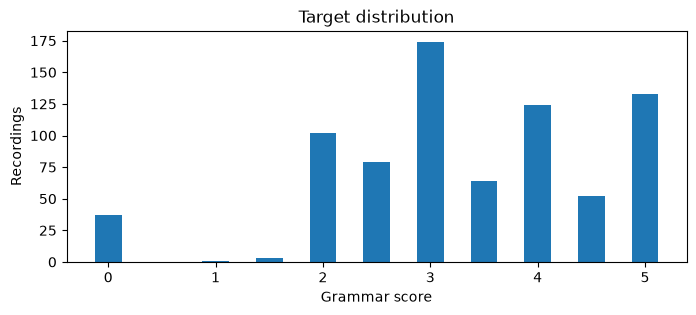

In [6]:
display(train_df[target_col].describe())
display(train_df[target_col].value_counts().sort_index().rename('exact_score_count'))
print('Fraction with decimal scores:',np.mean(~np.isclose(y,np.round(y))))
display(pd.Series(np.clip(np.rint(y),0,5)).value_counts().sort_index().rename('nearest_grammar_level'))
plt.figure(figsize=(8,3)); plt.hist(y,bins=np.arange(-.125,5.26,.25)); plt.xlabel('Grammar score'); plt.ylabel('Recordings'); plt.title('Target distribution'); plt.show()

## 7. Audio Inspection
Audio is processed sequentially, converted to mono and resampled to 16 kHz. ASR uses peak normalization only to prevent clipping; pauses are preserved. Acoustic amplitude features use the original resampled signal to avoid removing all loudness variation. Low-energy thresholds below are pause proxies, not a voice-activity detector.

In [7]:
def load_audio(path, normalize=False):
    a, sr = sf.read(path,dtype='float32',always_2d=True)
    a = a.mean(axis=1)
    if not len(a) or not np.isfinite(a).all(): raise ValueError('Empty or nonfinite waveform')
    if sr != AUDIO_SAMPLE_RATE:
        g = math.gcd(int(sr),AUDIO_SAMPLE_RATE)
        a = resample_poly(a,AUDIO_SAMPLE_RATE//g,int(sr)//g).astype('float32')
    if normalize:
        peak = np.max(np.abs(a))
        if peak > 1: a = a/peak
    return a

def inspect_audio(paths, split):
    rows=[]
    for p in tqdm(paths,desc=f'Inspect {split}'):
        record={'filename':p.name,'split':split,'path':str(p),'sha256':file_digest(p)}
        try:
            info=sf.info(p)
            # Read all frames sequentially to detect malformed payloads, not just valid headers.
            a=load_audio(p)
            record.update(duration=len(a)/AUDIO_SAMPLE_RATE,sample_rate=info.samplerate,channels=info.channels,
                          peak=float(np.max(np.abs(a))),audio_error='')
        except Exception as e:
            record.update(duration=np.nan,sample_rate=np.nan,channels=np.nan,peak=np.nan,audio_error=str(e))
            warnings.warn(f'Corrupt audio {p}: {e}')
        rows.append(record)
    return pd.DataFrame(rows)
train_audio = inspect_audio(train_paths,'train')
test_audio = inspect_audio(test_paths,'test')
audio_info = pd.concat([train_audio,test_audio],ignore_index=True)
audio_info.to_csv(OUTPUT_DIR/'audio_audit.csv',index=False)
display(audio_info.groupby('split').duration.describe()); display(audio_info.groupby(['split','sample_rate']).size())
display(audio_info.loc[audio_info.audio_error.ne('')])
print('Exact duplicate training audio:', train_audio.sha256.duplicated().sum())
content_overlap=set(train_audio.sha256)&set(test_audio.sha256)
print('Exact train/test audio content overlap:',len(content_overlap))
if content_overlap: raise ValueError('Train/test audio content overlap: investigate dataset before scoring')
groups = train_audio.sha256.to_numpy()
fig,ax=plt.subplots(1,2,figsize=(11,3))
for name,g in audio_info.groupby('split'): ax[0].hist(g.duration.dropna(),bins=25,alpha=.5,label=name)
ax[0].legend(); ax[0].set_title('Audio durations'); ax[0].set_xlabel('Seconds')
ax[1].scatter(train_audio.duration,y,alpha=.5); ax[1].set(xlabel='Duration (seconds)',ylabel='Grammar score'); plt.show()
for i in np.linspace(0,len(train_paths)-1,3,dtype=int):
    if train_audio.iloc[i].audio_error: continue
    a=load_audio(train_paths[i]); fig,ax=plt.subplots(1,2,figsize=(12,2.5))
    ax[0].plot(np.arange(len(a))/AUDIO_SAMPLE_RATE,a,lw=.4); ax[0].set_title(f'{train_paths[i].name}: score {y[i]}')
    mel=librosa.power_to_db(librosa.feature.melspectrogram(y=a,sr=AUDIO_SAMPLE_RATE,n_mels=64),ref=np.max)
    ax[1].imshow(mel,aspect='auto',origin='lower',extent=[0,len(a)/AUDIO_SAMPLE_RATE,0,64]); ax[1].set_title('Mel spectrogram'); plt.show()
release_memory()

## 8. ASR / Speech-to-Text
English Whisper runs locally through faster-whisper: `base.en` in fast mode, `medium.en` in full mode. No VAD trimming, no grammar-correcting prompt, no transcript fabrication. Whisper can nevertheless normalize grammatical errors: this is an important modeling limitation. Failure flags are retained; failed files have empty transcripts and missing metadata. More than 5% failures halts the pipeline rather than silently replacing the task with an acoustic model.

References: [faster-whisper](https://github.com/SYSTRAN/faster-whisper), [model license](https://huggingface.co/Systran/faster-whisper-small). Cache entries store segments, settings, audio hashes and error states. Failed entries are retried on later runs.

In [8]:
from faster_whisper import WhisperModel
asr_settings={'model':ASR_MODEL,'language':'en','beam_size':1 if FAST_MODE else 5,
              'condition_on_previous_text':False,'vad_filter':False,'version':versions['faster-whisper'],'schema':2}
asr_dir=CACHE_DIR/'asr'; asr_dir.mkdir(exist_ok=True)
asr_model=None
from concurrent.futures import ThreadPoolExecutor
from threading import Lock
model_lock=Lock()

def transcribe(paths,info,split):
    locks={h:Lock() for h in info.sha256}
    def process(pair):
        global asr_model
        p,h=pair
        with locks[h]:
            key=digest({'audio':h,'settings':asr_settings})
            cache=asr_dir/f'{key}.json'
            rec=None
            if cache.exists() and not FORCE_RECOMPUTE_TRANSCRIPTS:
                saved=json.loads(cache.read_text())
                if not saved.get('asr_error'): rec=saved
            if rec is None:
                with model_lock:
                    if asr_model is None:
                        asr_model=WhisperModel(ASR_MODEL,device=DEVICE,compute_type='float16' if DEVICE=='cuda' else 'int8',cpu_threads=ASR_CPU_THREADS,num_workers=ASR_WORKERS)
                try:
                    a=load_audio(p,normalize=True)
                    segments,meta=asr_model.transcribe(a,language='en',beam_size=asr_settings['beam_size'],vad_filter=False,condition_on_previous_text=False,temperature=0)
                    segs=[{'start':s.start,'end':s.end,'text':s.text,'avg_logprob':s.avg_logprob,'no_speech_prob':s.no_speech_prob} for s in segments]
                    gaps=[max(0,b['start']-a['end']) for a,b in zip(segs,segs[1:])]
                    rec={'transcript':' '.join(s['text'].strip() for s in segs),'n_segments':len(segs),
                         'avg_logprob':float(np.mean([s['avg_logprob'] for s in segs])) if segs else None,
                         'no_speech_prob':float(np.mean([s['no_speech_prob'] for s in segs])) if segs else None,
                         'segment_gap_mean':float(np.mean(gaps)) if gaps else None,
                         'segments':segs,'asr_error':'','audio_hash':h,'settings':asr_settings}
                except Exception as e:
                    warnings.warn(f'ASR failed for {p}: {e}')
                    rec={'transcript':'','n_segments':0,'avg_logprob':None,'no_speech_prob':None,'segment_gap_mean':None,'segments':[], 'asr_error':str(e),'audio_hash':h,'settings':asr_settings}
                atomic_json(cache,rec)
            return {'filename':p.name,**{k:v for k,v in rec.items() if k not in ['segments','settings']}}
    # executor.map preserves row order; at most ASR_WORKERS waveforms/models are active.
    with ThreadPoolExecutor(max_workers=ASR_WORKERS) as pool:
        rows=list(tqdm(pool.map(process,zip(paths,info.sha256)),total=len(paths),desc=f'Transcribe {split}'))
    df=pd.DataFrame(rows)
    df.to_csv(OUTPUT_DIR/f'{split}_transcripts.csv',index=False)
    if df.asr_error.ne('').mean()>MAX_ASR_FAILURE_FRACTION: raise RuntimeError(f'Too many ASR failures in {split}; inspect errors')
    return df
train_text=transcribe(train_paths,train_audio,'train')
test_text=transcribe(test_paths,test_audio,'test')
del asr_model
release_memory()

## 9. Transcript Analysis

In [9]:
def normalize_text(s): return re.sub(r'\s+',' ',str(s)).strip()
for df in [train_text,test_text]:
    df['normalized']=df.transcript.map(normalize_text)
    df['asr_failed']=df.asr_error.ne('').astype(int)
    df['empty_transcript']=df.normalized.str.len().eq(0).astype(int)
print('ASR diagnostics:')
for name,df in [('train',train_text),('test',test_text)]:
    print(name,df[['asr_failed','empty_transcript']].sum().to_dict())
display(train_text[['filename','transcript','avg_logprob']].head())
if train_text.empty_transcript.mean()>.1: raise RuntimeError('Too many empty transcripts; inspect ASR output')

## 10. Linguistic Feature Engineering
Counts and syntax are proxies, not measured grammar-error rates. Sentence boundaries are supplied by ASR and may be unreliable. spaCy parsing and local LanguageTool are optional: availability is reported explicitly, and absent signals are omitted. LanguageTool is disabled by default (Java/download cost); it never calls a remote grammar API.

In [10]:
nlp=None; grammar_tool=None
try:
    import spacy
    nlp=spacy.load('en_core_web_sm',disable=['ner'])
except (ImportError,OSError) as e: print('Optional spaCy parser unavailable; using lexical features:',e)
if USE_GRAMMAR_CHECKER:
    try:
        import language_tool_python
        grammar_tool=language_tool_python.LanguageTool('en-US')
    except Exception as e: warnings.warn(f'Local grammar checker unavailable: {e}')

def linguistic_features(text):
    words=re.findall(r"[a-z]+(?:'[a-z]+)?",text.lower()); n=len(words); denom=max(n,1)
    sentences=[re.findall(r"[a-z]+(?:'[a-z]+)?",s.lower()) for s in re.split(r'[.!?]+',text) if s.strip()]
    lengths=[len(s) for s in sentences] or [0]
    counts=Counter(words); fillers=sum(counts[w] for w in ['um','uh','erm','hmm'])
    out={'word_count':n,'unique_words':len(counts),'char_count':len(text),'sentence_count':len(sentences),
         'sentence_len_mean':np.mean(lengths),'sentence_len_median':np.median(lengths),'sentence_len_max':max(lengths),
         'type_token_ratio':len(counts)/denom,'root_ttr':len(counts)/math.sqrt(denom),
         'hapax_ratio':sum(v==1 for v in counts.values())/denom,'mean_word_length':np.mean([len(w) for w in words]) if words else 0,
         'fillers':fillers,'filler_ratio':fillers/denom,'adjacent_repeat_ratio':sum(a==b for a,b in zip(words,words[1:]))/denom,
         'short_sentence_ratio':np.mean(np.array(lengths)<3),'hesitation_marks':len(re.findall(r'\.\.\.|—|--',text)),
         'self_correction_proxy':len(re.findall(r'\b(i mean|sorry|rather|let me)\b',text.lower())),
         'discourse_filler_proxy':len(re.findall(r'\b(you know|well|like)\b',text.lower()))/denom}
    for k in [2,3]:
        grams=Counter(tuple(words[i:i+k]) for i in range(max(0,n-k+1)))
        out[f'repeated_{k}gram_ratio']=sum(v-1 for v in grams.values())/max(n-k+1,1)
    if nlp is not None:
        doc=nlp(text); tokens=[t for t in doc if not t.is_space]; nt=max(len(tokens),1)
        for pos in ['NOUN','VERB','ADJ','ADV','PRON','AUX','SCONJ','CCONJ','DET','ADP','PUNCT']:
            out['pos_'+pos]=sum(t.pos_==pos for t in tokens)/nt
        out['dependency_depth']=np.mean([len(list(t.ancestors)) for t in tokens]) if tokens else 0
        out['dependency_distance']=np.mean([abs(t.i-t.head.i) for t in tokens]) if tokens else 0
        out['clauses_per_sentence']=sum(t.dep_ in ['ROOT','ccomp','xcomp','advcl','relcl'] for t in tokens)/max(len(list(doc.sents)),1)
        out['verbs_per_sentence']=sum(t.pos_ in ['VERB','AUX'] for t in tokens)/max(len(list(doc.sents)),1)
        out['subordinate_proxy']=sum(t.dep_ in ['advcl','relcl','ccomp'] for t in tokens)/nt
        out['verbless_sentence_ratio']=np.mean([not any(t.pos_ in ['VERB','AUX'] for t in s) for s in doc.sents]) if tokens else 0
    if grammar_tool is not None:
        try:
            matches=grammar_tool.check(text)
            out['grammar_errors']=len(matches); out['grammar_errors_per_100_words']=100*len(matches)/denom
            for category in ['GRAMMAR','TYPOS','PUNCTUATION','CONFUSED_WORDS']:
                out['grammar_'+category]=sum(str(m.category)==category for m in matches)
        except Exception as e:
            warnings.warn(f'Grammar check failed: {e}'); out['grammar_errors']=np.nan; out['grammar_errors_per_100_words']=np.nan
    return out
all_text=pd.concat([train_text,test_text],ignore_index=True)
ling=pd.DataFrame([linguistic_features(s) for s in tqdm(all_text.normalized,desc='Linguistic features')])
ling.to_csv(OUTPUT_DIR/'linguistic_features.csv',index=False)
display(ling.head())
if grammar_tool is not None: grammar_tool.close()

## 11. Audio Feature Engineering

In [11]:
def acoustic_features(path,audio_hash):
    cp=CACHE_DIR/f'audio_{digest([audio_hash,AUDIO_SAMPLE_RATE,versions["librosa"],3])}.json'
    if cp.exists(): return json.loads(cp.read_text())
    try:
        a=load_audio(path); hop=320
        rms=librosa.feature.rms(y=a,frame_length=640,hop_length=hop)[0]
        threshold=max(float(np.max(rms))*.08,1e-5); quiet=rms<threshold
        changes=np.diff(np.r_[False,quiet,False].astype(int))
        pauses=(np.where(changes==-1)[0]-np.where(changes==1)[0])*hop/AUDIO_SAMPLE_RATE
        pauses=pauses[pauses>=.2]
        out={'audio_failed':0,'duration':len(a)/AUDIO_SAMPLE_RATE,'silence_ratio':float(quiet.mean()),
             'pause_count':len(pauses),'pause_mean':float(pauses.mean()) if len(pauses) else 0,'pause_max':float(pauses.max()) if len(pauses) else 0}
        features={'mfcc':librosa.feature.mfcc(y=a,sr=AUDIO_SAMPLE_RATE,n_mfcc=13,hop_length=hop),
                  'rms':rms[None,:],'centroid':librosa.feature.spectral_centroid(y=a,sr=AUDIO_SAMPLE_RATE,hop_length=hop),
                  'bandwidth':librosa.feature.spectral_bandwidth(y=a,sr=AUDIO_SAMPLE_RATE,hop_length=hop),
                  'rolloff':librosa.feature.spectral_rolloff(y=a,sr=AUDIO_SAMPLE_RATE,hop_length=hop),
                  'zcr':librosa.feature.zero_crossing_rate(y=a,hop_length=hop)}
        for name,arr in features.items():
            for j,row in enumerate(arr):
                out[f'{name}_{j}_mean']=float(np.mean(row)); out[f'{name}_{j}_std']=float(np.std(row))
        atomic_json(cp,out); return out
    except Exception as e:
        warnings.warn(f'Audio feature failure {path}: {e}'); return {'audio_failed':1}
if USE_AUDIO_FEATURES:
    acoust=pd.DataFrame([acoustic_features(p,h) for p,h in tqdm(list(zip(train_paths+test_paths,audio_info.sha256)),desc='Acoustic features')])
    acoust['words_per_second']=ling.word_count/np.maximum(acoust.duration,.1)
    acoust['words_per_active_second']=ling.word_count/np.maximum(acoust.duration*(1-acoust.silence_ratio),.1)
    acoust.to_csv(OUTPUT_DIR/'acoustic_features.csv',index=False)
else: acoust=pd.DataFrame(index=np.arange(len(all_text)))

## 12. Text Embeddings
Frozen sentence-transformer embeddings need no fitting on competition labels. Long transcripts are token-chunked and pooled so endings are not silently truncated. Each transcript embedding is resumable and keyed by text, model and library version. Do not switch a mutable local model directory in place without clearing its cache.

[MiniLM model card (Apache-2.0)](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2); [MPNet model card](https://huggingface.co/sentence-transformers/all-mpnet-base-v2). Model licenses and competition terms should be retained with published artifacts. Lexical TF-IDF is separately tested inside folds to preserve grammatical surface patterns that semantic embeddings can miss.

In [12]:
from sentence_transformers import SentenceTransformer
encoder=SentenceTransformer(TEXT_EMBEDDING_MODEL,device=DEVICE)
encoder.eval()
emb_dir=CACHE_DIR/'embeddings'; emb_dir.mkdir(exist_ok=True)
def embed_transcript(text):
    key=digest([TEXT_EMBEDDING_MODEL,versions['sentence-transformers'],text,2])
    cp=emb_dir/f'{key}.npy'
    if cp.exists() and not FORCE_RECOMPUTE_EMBEDDINGS: return np.load(cp)
    tokens=encoder.tokenizer.encode(text,add_special_tokens=False)
    chunk_size=max(16,int(encoder.max_seq_length)-8)
    chunks=[tokens[i:i+chunk_size] for i in range(0,len(tokens),chunk_size)] or [[]]
    strings=[encoder.tokenizer.decode(c,skip_special_tokens=True) for c in chunks]
    with torch.inference_mode():
        e=encoder.encode(strings,batch_size=16,show_progress_bar=False,convert_to_numpy=True,normalize_embeddings=True)
    v=np.average(e,axis=0,weights=[max(1,len(c)) for c in chunks]).astype('float32')
    v=v/max(np.linalg.norm(v),1e-12)
    with cp.with_suffix('.tmp').open('wb') as f: np.save(f,v)
    cp.with_suffix('.tmp').replace(cp)
    return v
emb=np.vstack([embed_transcript(s) for s in tqdm(all_text.normalized,desc='Text embeddings')])
np.save(OUTPUT_DIR/'text_embeddings.npy',emb)
del encoder
release_memory()
print('Embedding matrix:',emb.shape)

## 13. Feature Assembly

In [13]:
metadata=all_text[['n_segments','avg_logprob','no_speech_prob','segment_gap_mean','asr_failed','empty_transcript']].apply(pd.to_numeric,errors='coerce')
# A is strictly linguistic. ASR quality indicators belong only to D with acoustic features.
ling=ling.replace([np.inf,-np.inf],np.nan)
emb_df=pd.DataFrame(emb,columns=[f'emb_{i}' for i in range(emb.shape[1])])
feature_frames={'B_embeddings':emb_df}
if USE_LINGUISTIC_FEATURES:
    feature_frames['A_linguistic']=ling
    feature_frames['C_text_combined']=pd.concat([emb_df,ling],axis=1)
if USE_AUDIO_FEATURES:
    feature_frames['D_multimodal']=pd.concat([emb_df,ling if USE_LINGUISTIC_FEATURES else pd.DataFrame(index=ling.index),metadata,acoust],axis=1)
    feature_frames['audio_only']=acoust  # negative-control/ablation, not assumed to measure grammar
ntrain=len(train_df)
Xsets={k:v.iloc[:ntrain].to_numpy(dtype=float,copy=True) for k,v in feature_frames.items()}
Tsets={k:v.iloc[ntrain:].to_numpy(dtype=float,copy=True) for k,v in feature_frames.items()}
for k in Xsets:
    assert len(Xsets[k])==len(y) and len(Tsets[k])==len(test_df)
    Xsets[k][~np.isfinite(Xsets[k])]=np.nan; Tsets[k][~np.isfinite(Tsets[k])]=np.nan
print({k:v.shape for k,v in Xsets.items()})
# No target, filename, path, test label, or identity feature is included.

{'B_embeddings': (769, 384), 'A_linguistic': (769, 37), 'C_text_combined': (769, 421), 'D_multimodal': (769, 471), 'audio_only': (769, 44)}


## 14. Cross-Validation Strategy
Identical audio hashes stay in one fold. Score quantiles permit stratification only when every bin is large enough; otherwise use shuffled folds. Speaker IDs are not provided: distinct recordings from the same unknown speaker cannot be reliably grouped. This is a validation limitation. All imputation, scaling, TF-IDF vocabulary and PCA fitting happen inside each training fold.

In [14]:
def make_folds(target,group_ids,n_splits,seed):
    unique_groups=len(np.unique(group_ids)); n_splits=min(n_splits,unique_groups)
    if n_splits<2: raise ValueError('Not enough independent recordings for validation')
    bins=None
    for q in range(min(10,len(target)//n_splits),1,-1):
        b=pd.qcut(pd.Series(target),q=q,labels=False,duplicates='drop')
        if b.nunique()>1 and b.value_counts().min()>=n_splits:
            bins=b.to_numpy(); break
    dummy=np.zeros(len(target))
    if unique_groups<len(target):
        splitter=StratifiedGroupKFold(n_splits=n_splits,shuffle=True,random_state=seed) if bins is not None else GroupKFold(n_splits=n_splits)
        return list(splitter.split(dummy,bins if bins is not None else target,group_ids))
    splitter=StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed) if bins is not None else KFold(n_splits=n_splits,shuffle=True,random_state=seed)
    return list(splitter.split(dummy,bins))
folds=make_folds(y,groups,N_FOLDS,SEED)
fold_id=np.full(len(y),-1)
for f,(tr,va) in enumerate(folds):
    assert not set(groups[tr]) & set(groups[va]); fold_id[va]=f
assert (fold_id>=0).all()
pd.DataFrame({'filename':train_df[filename_col],'fold':fold_id,'target':y,'audio_hash':groups}).to_csv(OUTPUT_DIR/'folds.csv',index=False)

def metrics(target,pred):
    pred=np.asarray(pred,dtype=float)
    assert np.isfinite(pred).all()
    corr=float(pearsonr(target,pred)[0]) if np.std(pred)>1e-12 and np.std(target)>1e-12 else np.nan
    return {'RMSE':float(np.sqrt(mean_squared_error(target,pred))),'Pearson':corr}
def bounded(p): return np.clip(p,TARGET_MIN,TARGET_MAX)
results=[]; oof={}; specs={}; fold_rows=[]
def register_result(name,pred):
    oof[name]=np.asarray(pred)
    row={'Model':name,**metrics(y,pred)}
    fr=[]
    for f,(_,va) in enumerate(folds):
        m=metrics(y[va],pred[va]); fr.append(m); fold_rows.append({'Model':name,'fold':f,**m})
    for metric in ['RMSE','Pearson']:
        vals=np.array([m[metric] for m in fr]); row[metric+'_mean']=float(np.nanmean(vals)) if np.isfinite(vals).any() else np.nan
        row[metric+'_std']=float(np.nanstd(vals,ddof=1)) if np.isfinite(vals).sum()>1 else np.nan
    results.append(row); print(row)
    pd.DataFrame(results).to_csv(OUTPUT_DIR/'model_results.csv',index=False)

def numeric_pipeline(est,pca=False):
    steps=[('impute',SimpleImputer(strategy='median',add_indicator=True,keep_empty_features=True)),('scale',StandardScaler())]
    if pca: steps.append(('pca',PCA(n_components=.95,svd_solver='full')))
    return Pipeline(steps+[('model',est)])
def evaluate(name,feature,est,pca=False,text=False):
    X=np.array(train_text.normalized) if text else Xsets[feature]
    pipe=est if text else numeric_pipeline(est,pca)
    pred=np.full(len(y),np.nan)
    for tr,va in tqdm(folds,desc=name,leave=False):
        fitted=clone(pipe).fit(X[tr],y[tr]); pred[va]=bounded(fitted.predict(X[va]))
    specs[name]={'feature':feature,'pipeline':pipe,'text':text}
    register_result(name,pred)

## 15. Baseline Models

In [15]:
baseline_feature=next(iter(Xsets))
evaluate('Mean baseline',baseline_feature,DummyRegressor())
for feature in Xsets:
    for alpha in [10.,100.]: evaluate(f'{feature} Ridge {alpha:g}',feature,Ridge(alpha=alpha))
if 'A_linguistic' in Xsets:
    evaluate('Linguistic ElasticNet','A_linguistic',ElasticNet(alpha=.03,l1_ratio=.15,max_iter=10000,random_state=SEED))
tfidf_pipe=Pipeline([('tfidf',TfidfVectorizer(ngram_range=(1,2),min_df=2,max_features=12000,sublinear_tf=True)),('model',Ridge(alpha=10,solver='lsqr'))])
evaluate('Transcript TF-IDF Ridge',None,tfidf_pipe,text=True)

Mean baseline:   0%|          | 0/5 [00:00<?, ?it/s]

{'Model': 'Mean baseline', 'RMSE': 1.238465782056706, 'Pearson': -0.027929875096286343, 'RMSE_mean': 1.237508550857702, 'RMSE_std': 0.05509821817978313, 'Pearson_mean': nan, 'Pearson_std': nan}


B_embeddings Ridge 10:   0%|          | 0/5 [00:00<?, ?it/s]

{'Model': 'B_embeddings Ridge 10', 'RMSE': 1.161733934480737, 'Pearson': 0.5165984905636531, 'RMSE_mean': 1.158049207058371, 'RMSE_std': 0.10450212424449677, 'Pearson_mean': 0.5118283750141771, 'Pearson_std': 0.11312989557549757}


B_embeddings Ridge 100:   0%|          | 0/5 [00:00<?, ?it/s]

...

Linguistic ElasticNet:   0%|          | 0/5 [00:00<?, ?it/s]

{'Model': 'Linguistic ElasticNet', 'RMSE': 1.0850508408186803, 'Pearson': 0.490997436507349, 'RMSE_mean': 1.0848424372455052, 'RMSE_std': 0.02558248411924241, 'Pearson_mean': 0.48794239387748073, 'Pearson_std': 0.034935465801947584}


Transcript TF-IDF Ridge:   0%|          | 0/5 [00:00<?, ?it/s]

Transcript TF-IDF Ridge:  60%|██████    | 3/5 [00:00<00:00, 20.25it/s]

{'Model': 'Transcript TF-IDF Ridge', 'RMSE': 1.16995723687579, 'Pearson': 0.5641066687471481, 'RMSE_mean': 1.1689704389937199, 'RMSE_std': 0.05417090905522062, 'Pearson_mean': 0.5693022337654365, 'Pearson_std': 0.034687004180475954}


## 16. Advanced Models

In [16]:
tree_count=180 if FAST_MODE else 500
for feature in Xsets:
    if feature=='audio_only': continue
    evaluate(f'{feature} ExtraTrees',feature,ExtraTreesRegressor(n_estimators=tree_count,min_samples_leaf=4,max_features=.7,n_jobs=-1,random_state=SEED))
rich='D_multimodal' if 'D_multimodal' in Xsets else ('C_text_combined' if 'C_text_combined' in Xsets else 'B_embeddings')
evaluate('Multimodal RandomForest',rich,RandomForestRegressor(n_estimators=tree_count,min_samples_leaf=5,max_features=.6,n_jobs=-1,random_state=SEED))
evaluate('Multimodal HistGradientBoosting',rich,HistGradientBoostingRegressor(max_iter=150,learning_rate=.04,max_leaf_nodes=10,l2_regularization=8,early_stopping=False,random_state=SEED))
# Optional imports fail visibly and do not prevent core sklearn experiments.
for package in ['catboost','lightgbm','xgboost']:
    try: module=importlib.import_module(package)
    except Exception as e:
        print(f'Optional {package} skipped:',e); continue
    if package=='catboost': est=module.CatBoostRegressor(iterations=400,depth=4,learning_rate=.035,l2_leaf_reg=10,loss_function='RMSE',verbose=False,random_seed=SEED,allow_writing_files=False,thread_count=4)
    elif package=='lightgbm': est=module.LGBMRegressor(n_estimators=250,num_leaves=10,max_depth=4,learning_rate=.035,min_child_samples=25,reg_lambda=10,verbosity=-1,n_jobs=4,random_state=SEED)
    else: est=module.XGBRegressor(n_estimators=250,max_depth=3,learning_rate=.035,reg_lambda=10,min_child_weight=10,subsample=.9,colsample_bytree=.8,objective='reg:squarederror',n_jobs=4,random_state=SEED)
    evaluate(f'Multimodal {package}',rich,est)

## 17. PCA Experiments

In [17]:
if USE_PCA:
    # Clean embedding-only comparison; no PCA mixing interpretable linguistic columns.
    for alpha in [10.,100.]: evaluate(f'Embeddings PCA95 Ridge {alpha:g}','B_embeddings',Ridge(alpha=alpha),pca=True)

Embeddings PCA95 Ridge 10:   0%|          | 0/5 [00:00<?, ?it/s]

Embeddings PCA95 Ridge 10:  80%|████████  | 4/5 [00:00<00:00, 36.31it/s]

{'Model': 'Embeddings PCA95 Ridge 10', 'RMSE': 1.0385998959913691, 'Pearson': 0.5731291108223827, 'RMSE_mean': 1.0360004691776152, 'RMSE_std': 0.0826259842911302, 'Pearson_mean': 0.5714715268150898, 'Pearson_std': 0.07473595180184793}


Embeddings PCA95 Ridge 100:   0%|          | 0/5 [00:00<?, ?it/s]

Embeddings PCA95 Ridge 100:  80%|████████  | 4/5 [00:00<00:00, 36.59it/s]

{'Model': 'Embeddings PCA95 Ridge 100', 'RMSE': 1.0120520844577316, 'Pearson': 0.5862060091385497, 'RMSE_mean': 1.0093430491504873, 'RMSE_std': 0.08311992239325151, 'Pearson_mean': 0.584576840229521, 'Pearson_std': 0.07593935723190423}


## 18. Ensemble Experiments
Only a small set of weights is tested. Selection uses RMSE, breaking near ties by correlation and requiring non-degraded correlation for accepting additions. Positive affine rescaling alone cannot improve Pearson; clipping may change it.

Calibration is evaluated with **nested training**: for each outer fold, inner OOF predictions are generated using only outer-training labels, and an affine map is fitted there. Applying a regressor to globally generated OOF predictions and then randomly splitting them would leak labels through the base models. This notebook avoids that shortcut.

Choosing models and weights on these same outer folds introduces selection optimism. The scores are development CV estimates, not an unbiased nested evaluation of the entire search. Reserve a final holdout or run fully nested model selection for stronger claims.

In [18]:
ranking=pd.DataFrame(results).sort_values(['RMSE','Pearson'],ascending=[True,False])
best_single=ranking.iloc[0]['Model']
# Prefer diverse families among the high-performing candidates.
def family(name):
    for tag in ['TF-IDF','Ridge','ExtraTrees','RandomForest','HistGradient','catboost','lightgbm','xgboost','ElasticNet']:
        if tag in name: return tag
    return name
members=[]; families=set()
for name in ranking.Model:
    if name=='Mean baseline': continue
    if family(name) not in families:
        members.append(name); families.add(family(name))
    if len(members)==3: break
blend_specs={}
if len(members)>=2:
    candidates=[('Blend equal2',members[:2],np.array([.5,.5])),('Blend 75-25',members[:2],np.array([.75,.25]))]
    if len(members)==3: candidates.append(('Blend equal3',members,np.ones(3)/3))
    for name,ms,ws in candidates:
        p=bounded(sum(w*oof[m] for m,w in zip(ms,ws)))
        blend_specs[name]=list(zip(ms,ws.tolist())); register_result(name,p)
chosen=best_single
for name in blend_specs:
    old,new=metrics(y,oof[chosen]),metrics(y,oof[name])
    if new['RMSE']<old['RMSE'] and new['Pearson']>=old['Pearson']-.005: chosen=name
selected_members=blend_specs.get(chosen,[(chosen,1.)])
uncalibrated_name=chosen
calibration_enabled=False
calibration_outer=[]
if RUN_CALIBRATION:
    cal_pred=np.full(len(y),np.nan)
    for f,(tr,va) in enumerate(tqdm(folds,desc='Nested affine calibration')):
        inner=make_folds(y[tr],groups[tr],min(3,N_FOLDS),SEED+f+100)
        inner_blend=np.zeros(len(tr))
        for name,weight in selected_members:
            spec=specs[name]; X=np.array(train_text.normalized) if spec['text'] else Xsets[spec['feature']]
            inner_pred=np.full(len(tr),np.nan)
            for it,iv in inner:
                model=clone(spec['pipeline']).fit(X[tr[it]],y[tr[it]])
                inner_pred[iv]=bounded(model.predict(X[tr[iv]]))
            inner_blend+=weight*inner_pred
        cal=LinearRegression().fit(inner_blend.reshape(-1,1),y[tr])
        # A negative or extreme slope is not a sensible small-data calibration.
        if not .5<=float(cal.coef_[0])<=1.5:
            cal_pred[va]=oof[chosen][va]; calibration_outer.append({'fold':f,'slope':float(cal.coef_[0]),'applied':False})
        else:
            cal_pred[va]=bounded(cal.predict(oof[chosen][va,None])); calibration_outer.append({'fold':f,'slope':float(cal.coef_[0]),'applied':True})
    calibrated_name=chosen+' + nested calibration'; register_result(calibrated_name,cal_pred)
    old,new=metrics(y,oof[chosen]),metrics(y,cal_pred)
    improvements=[metrics(y[va],oof[chosen][va])['RMSE']-metrics(y[va],cal_pred[va])['RMSE'] for _,va in folds]
    calibration_enabled=new['RMSE']<old['RMSE']-.002 and new['Pearson']>=old['Pearson']-.005 and sum(v>0 for v in improvements)>=math.ceil(len(folds)*.6) and all(r['applied'] for r in calibration_outer)
    if calibration_enabled: chosen=calibrated_name
print('Selected:',chosen,'members:',selected_members,'calibration:',calibration_enabled)

{'Model': 'Blend equal2', 'RMSE': 0.6725553382600765, 'Pearson': 0.8423264447904918, 'RMSE_mean': 0.671626530817538, 'RMSE_std': 0.03859568861725391, 'Pearson_mean': 0.8421128792609949, 'Pearson_std': 0.03282545630685697}
{'Model': 'Blend 75-25', 'RMSE': 0.670498372918557, 'Pearson': 0.8440451962636014, 'RMSE_mean': 0.6694152893298104, 'RMSE_std': 0.041581099413297566, 'Pearson_mean': 0.8437479901438735, 'Pearson_std': 0.03429183495966092}
{'Model': 'Blend equal3', 'RMSE': 0.67080880787195, 'Pearson': 0.8446825713911124, 'RMSE_mean': 0.6698457026660798, 'RMSE_std': 0.03913090785228148, 'Pearson_mean': 0.8439650255979145, 'Pearson_std': 0.03307544029724979}


Nested affine calibration:   0%|          | 0/5 [00:00<?, ?it/s]

Nested affine calibration:  20%|██        | 1/5 [00:09<00:38,  9.55s/it]

Nested affine calibration:  40%|████      | 2/5 [00:19<00:28,  9.55s/it]

Nested affine calibration:  60%|██████    | 3/5 [00:28<00:19,  9.61s/it]

Nested affine calibration:  80%|████████  | 4/5 [00:38<00:09,  9.76s/it]

Nested affine calibration: 100%|██████████| 5/5 [00:49<00:00, 10.05s/it]

Nested affine calibration: 100%|██████████| 5/5 [00:49<00:00,  9.87s/it]

{'Model': 'Blend 75-25 + nested calibration', 'RMSE': 0.660851610083379, 'Pearson': 0.84577894179478, 'RMSE_mean': 0.6595279665205159, 'RMSE_std': 0.04569967805571809, 'Pearson_mean': 0.8450923993306823, 'Pearson_std': 0.034778923355223444}
Selected: Blend 75-25 + nested calibration members: [('Multimodal catboost', 0.75), ('Multimodal HistGradientBoosting', 0.25)] calibration: True


## 19. Validation Results

,Model,RMSE,Pearson,RMSE_mean,RMSE_std,Pearson_mean,Pearson_std
25,Blend 75-25 + nested calibration,0.660852,0.845779,0.659528,0.045700,0.845092,0.034779
23,Blend 75-25,0.670498,0.844045,0.669415,0.041581,0.843748,0.034292
24,Blend equal3,0.670809,0.844683,0.669846,0.039131,0.843965,0.033075
19,Multimodal catboost,0.672288,0.843412,0.671004,0.045332,0.842955,0.036414
22,Blend equal2,0.672555,0.842326,0.671627,0.038596,0.842113,0.032825
18,Multimodal HistGradientBoosting,0.688006,0.832369,0.687247,0.035481,0.832166,0.031562
16,D_multimodal ExtraTrees,0.690616,0.834670,0.689628,0.040069,0.832852,0.035566
17,Multimodal RandomForest,0.700773,0.826928,0.699815,0.039941,0.825438,0.035527
8,D_multimodal Ridge 100,0.726987,0.809910,0.725428,0.051980,0.810866,0.028761
10,audio_only Ridge 100,0.849329,0.727776,0.847267,0.065177,0.723188,0.070639


,Model,fold,RMSE,Pearson
125,Blend 75-25 + nested calibration,0,0.717429,0.814104
126,Blend 75-25 + nested calibration,1,0.679535,0.825207
127,Blend 75-25 + nested calibration,2,0.611308,0.887903
128,Blend 75-25 + nested calibration,3,0.674975,0.820687
129,Blend 75-25 + nested calibration,4,0.614393,0.877561


,fold,slope,applied
0,0,1.105634,True
1,1,1.118280,True
2,2,1.114169,True
3,3,1.119660,True
4,4,1.132655,True


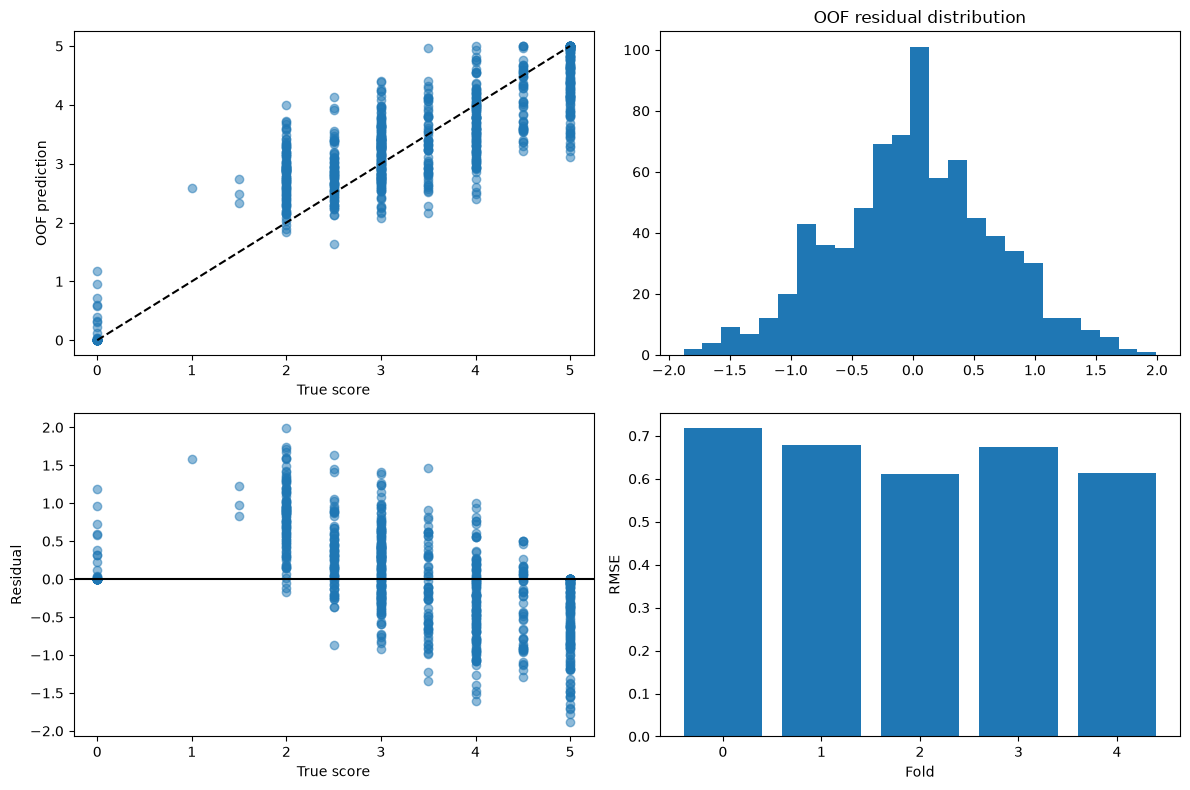

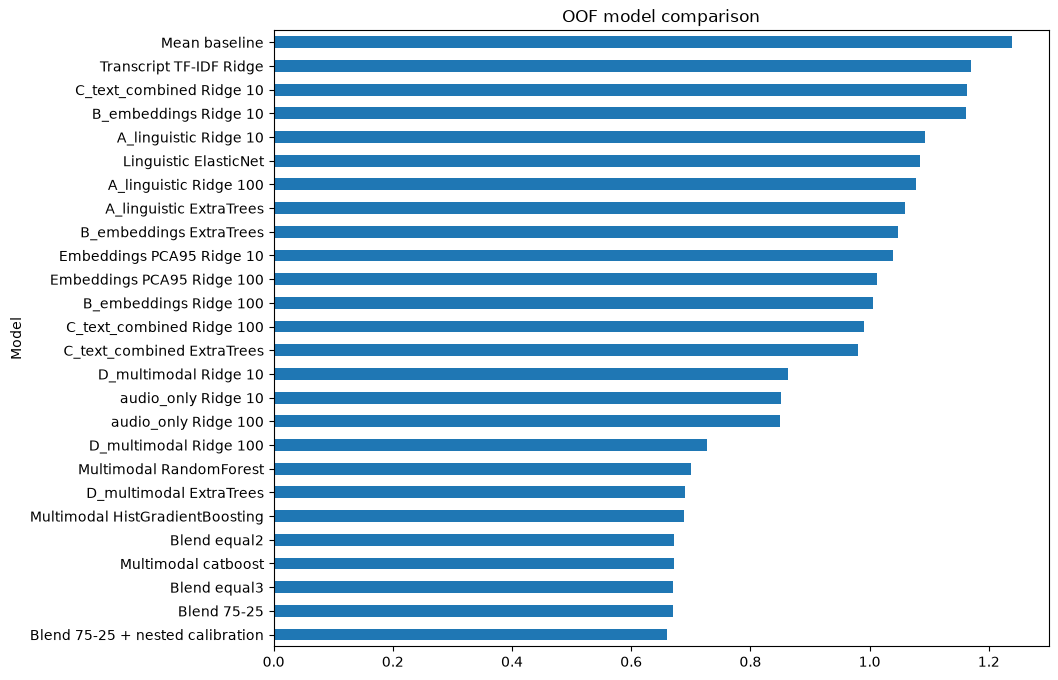

OOF target/prediction standard deviation: 1.2381936808002134 1.0322852756019834


In [19]:
results_df=pd.DataFrame(results).sort_values('RMSE')
fold_results=pd.DataFrame(fold_rows)
results_df.to_csv(OUTPUT_DIR/'model_results.csv',index=False); fold_results.to_csv(OUTPUT_DIR/'fold_metrics.csv',index=False)
display(results_df); display(fold_results[fold_results.Model==chosen])
if calibration_outer:
    display(pd.DataFrame(calibration_outer))
    pd.DataFrame(calibration_outer).to_csv(OUTPUT_DIR/'calibration_diagnostics.csv',index=False)
selected_oof=oof[chosen]
pd.DataFrame({'filename':train_df[filename_col],'target':y,'fold':fold_id,**oof}).to_csv(OUTPUT_DIR/'oof_predictions.csv',index=False)
fig,axs=plt.subplots(2,2,figsize=(12,8))
axs[0,0].scatter(y,selected_oof,alpha=.5); axs[0,0].plot([0,5],[0,5],'k--'); axs[0,0].set(xlabel='True score',ylabel='OOF prediction')
axs[0,1].hist(selected_oof-y,bins=25); axs[0,1].set_title('OOF residual distribution')
axs[1,0].scatter(y,selected_oof-y,alpha=.5); axs[1,0].axhline(0,color='black'); axs[1,0].set(xlabel='True score',ylabel='Residual')
sel_folds=fold_results[fold_results.Model==chosen]
axs[1,1].bar(sel_folds.fold,sel_folds.RMSE); axs[1,1].set(xlabel='Fold',ylabel='RMSE'); plt.tight_layout(); plt.show()
results_df.set_index('Model').RMSE.sort_values().plot.barh(figsize=(10,8),title='OOF model comparison'); plt.show()
print('OOF target/prediction standard deviation:',np.std(y),np.std(selected_oof))

## 20. Error Analysis

In [20]:
errors=pd.DataFrame({'filename':train_df[filename_col],'actual':y,'oof_prediction':selected_oof,'absolute_error':abs(y-selected_oof),'transcript':train_text.transcript,'asr_logprob':train_text.avg_logprob,'duration':train_audio.duration})
errors.to_csv(OUTPUT_DIR/'error_analysis.csv',index=False)
for title,rows in [('Best',errors.nsmallest(5,'absolute_error')),('Worst',errors.nlargest(5,'absolute_error')),('Low scores',errors.nsmallest(5,'actual')),('High scores',errors.nlargest(5,'actual'))]:
    print(title); display(rows)
display(errors.assign(score_band=pd.cut(y,[-.01,1,2,3,4,5])).groupby('score_band',observed=True).agg(count=('actual','size'),mean_absolute_error=('absolute_error','mean'),mean_prediction=('oof_prediction','mean')))

Review only training examples to investigate ASR mistakes, incomplete sentences, long pauses, vocabulary/topic effects, short effective speech and regression toward the mean. Accent/noise explanations require listening and cannot be inferred from error magnitude alone. Do not manually change labels or predictions. ASR punctuation and corrected grammar may obscure the very errors the model should detect.

## 21. Interpretability

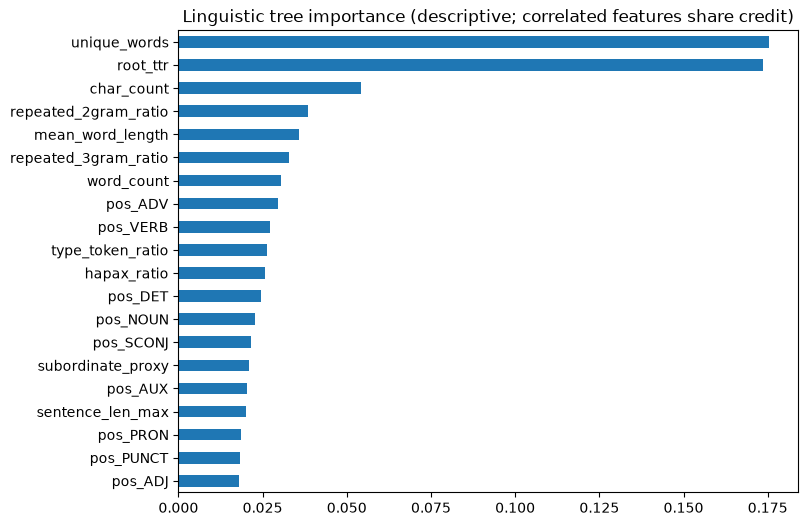

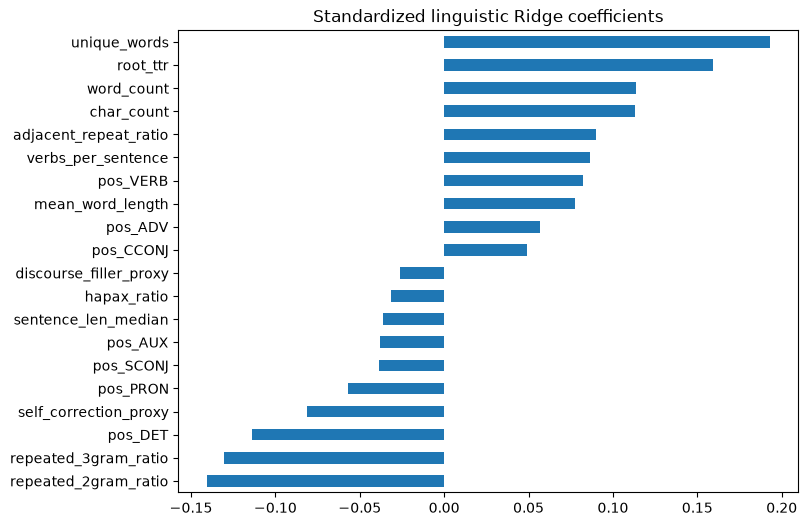

In [21]:
# Descriptive full-training fits for interpretation only; never fed into CV scores.
if 'A_linguistic' in Xsets:
    interpreter=numeric_pipeline(ExtraTreesRegressor(n_estimators=tree_count,min_samples_leaf=4,random_state=SEED,n_jobs=-1)).fit(Xsets['A_linguistic'],y)
    names=interpreter.named_steps['impute'].get_feature_names_out(feature_frames['A_linguistic'].columns)
    importance=pd.Series(interpreter.named_steps['model'].feature_importances_,index=names).sort_values()
    importance.tail(20).plot.barh(figsize=(8,6),title='Linguistic tree importance (descriptive; correlated features share credit)'); plt.show()
    lin=numeric_pipeline(Ridge(alpha=100)).fit(Xsets['A_linguistic'],y)
    coeff=pd.Series(lin.named_steps['model'].coef_,index=lin.named_steps['impute'].get_feature_names_out(feature_frames['A_linguistic'].columns)).sort_values()
    pd.concat([coeff.head(10),coeff.tail(10)]).drop_duplicates().plot.barh(figsize=(8,6),title='Standardized linguistic Ridge coefficients'); plt.show()
    importance.to_csv(OUTPUT_DIR/'linguistic_importance.csv')

## 22. Final Model Training

In [22]:
final_models=[]; train_prediction=np.zeros(len(y)); test_prediction=np.zeros(len(test_df))
for name,weight in selected_members:
    spec=specs[name]
    X=np.array(train_text.normalized) if spec['text'] else Xsets[spec['feature']]
    T=np.array(test_text.normalized) if spec['text'] else Tsets[spec['feature']]
    fitted=clone(spec['pipeline']).fit(X,y)
    train_prediction+=weight*bounded(fitted.predict(X)); test_prediction+=weight*bounded(fitted.predict(T))
    final_models.append({'name':name,'weight':weight,'feature':spec['feature'],'text':spec['text'],'model':fitted})
final_calibrator=None
if calibration_enabled:
    final_calibrator=LinearRegression().fit(oof[uncalibrated_name].reshape(-1,1),y)
    if not .5<=float(final_calibrator.coef_[0])<=1.5:
        raise RuntimeError('Final calibration slope unstable despite CV; rerun with RUN_CALIBRATION=False')
    train_prediction=final_calibrator.predict(train_prediction.reshape(-1,1))
    test_prediction=final_calibrator.predict(test_prediction.reshape(-1,1))
train_prediction=bounded(train_prediction); test_prediction=bounded(test_prediction)
joblib.dump({'models':final_models,'calibrator':final_calibrator,'feature_names':{k:v.columns.tolist() for k,v in feature_frames.items()},'asr_model':ASR_MODEL,'embedding_model':TEXT_EMBEDDING_MODEL,'seed':SEED,'versions':versions},OUTPUT_DIR/'final_models.joblib')

## 23. Required Training RMSE

In [23]:
train_metrics=metrics(y,train_prediction); oof_metrics=metrics(y,selected_oof)
pd.DataFrame({'filename':train_df[filename_col],'target':y,'prediction':train_prediction}).to_csv(OUTPUT_DIR/'training_predictions.csv',index=False)
print('='*30)
print('FINAL TRAINING METRICS')
print(f"Training RMSE: {train_metrics['RMSE']:.6f}")
print(f"Training Pearson: {train_metrics['Pearson']:.6f}")
print('='*30)
print('These are in-sample metrics. OOF metrics are more realistic, but model selection still introduces optimism.')
print('OOF RMSE:',oof_metrics['RMSE'],'OOF Pearson:',oof_metrics['Pearson'])
atomic_json(OUTPUT_DIR/'final_metrics.json',{'model':chosen,'training':train_metrics,'oof':oof_metrics,'calibration':calibration_enabled})

FINAL TRAINING METRICS
Training RMSE: 0.366269
Training Pearson: 0.957219
These are in-sample metrics. OOF metrics are more realistic, but model selection still introduces optimism.
OOF RMSE: 0.660851610083379 OOF Pearson: 0.84577894179478


## 24. Test Prediction

In [24]:
assert len(test_prediction)==len(test_df)
assert np.isfinite(test_prediction).all()
assert ((test_prediction>=TARGET_MIN)&(test_prediction<=TARGET_MAX)).all()
if np.std(test_prediction)<.05: warnings.warn('Predictions are nearly constant: investigate feature/ASR/model failures')
test_predictions=pd.DataFrame({sample_filename_col:test_df[test_filename_col].to_numpy(),pred_col:test_prediction})
test_predictions.to_csv(OUTPUT_DIR/'test_predictions.csv',index=False)
display(test_predictions.head(10))
print(pd.Series(test_prediction).agg(['min','max','mean','std']))

## 25. Submission Generation
Exact compatible template row order and columns are preserved by an explicit ID join. An incompatible template cannot be repaired by positional assignment or fabricated IDs. `strict` mode records the blocking issue while still completing metrics/report generation. `test_order` is an explicit user-approved alternative using the template schema and all test IDs; it does not pretend to preserve the broken template's IDs.

In [25]:
submission_path=OUTPUT_DIR/'submission.csv'
submission_written=False
if template_compatible:
    submission=sample_df.copy(deep=True)
    mapping=test_predictions.set_index(sample_filename_col)[pred_col]
    submission[pred_col]=submission[sample_filename_col].map(mapping)
    assert submission[sample_filename_col].equals(sample_df[sample_filename_col])
elif SUBMISSION_POLICY=='test_order':
    warnings.warn('Explicit test_order override: replacing incompatible template rows with test.csv IDs. Confirm this matches competition requirements.')
    submission=test_predictions[sample_df.columns].copy()
else:
    submission=None
    print('BLOCKED: incompatible sample_submission.csv. test_predictions.csv is complete; provide the correct template or authorize test_order.')
if submission is not None:
    assert list(submission.columns)==list(sample_df.columns)
    assert len(submission)==len(test_df)
    assert submission[pred_col].notna().all()
    assert pd.api.types.is_numeric_dtype(submission[pred_col])
    assert np.isfinite(submission[pred_col]).all()
    assert submission[pred_col].between(TARGET_MIN,TARGET_MAX).all()
    assert not submission[sample_filename_col].duplicated().any()
    assert set(submission[sample_filename_col])==set(test_df[test_filename_col])
    submission.to_csv(submission_path,index=False)
    reloaded=pd.read_csv(submission_path)
    assert reloaded[sample_filename_col].tolist()==submission[sample_filename_col].tolist()
    submission_written=True
    display(submission.head(10)); print('Saved:',submission_path.resolve())

## 26. Final Report / Conclusion

In [26]:
def markdown_table(df,columns):
    # Avoid making tabulate a dependency of report generation.
    rows=['| '+' | '.join(columns)+' |','| '+' | '.join(['---']*len(columns))+' |']
    for _,row in df.iterrows(): rows.append('| '+' | '.join(f'{row[c]:.5f}' if isinstance(row[c],(float,np.floating)) else str(row[c]) for c in columns)+' |')
    return '\n'.join(rows)
ablation_parts=[]
for feature in ['A_linguistic','B_embeddings','C_text_combined','D_multimodal','audio_only']:
    match=results_df.loc[results_df.Model.eq(feature+' Ridge 100')]
    if len(match): ablation_parts.append(f"{feature}: {match.iloc[0]['RMSE']:.4f}")
ablation_summary='; '.join(ablation_parts)
importance_summary=[]
for member in final_models:
    pipe=member['model']; estimator=pipe.named_steps['model']
    if member['feature'] is None or not hasattr(estimator,'feature_importances_'): continue
    columns=pipe.named_steps['impute'].get_feature_names_out(feature_frames[member['feature']].columns)
    values=np.asarray(estimator.feature_importances_,dtype=float)
    importance=pd.DataFrame({'feature':columns,'importance':values}).sort_values('importance',ascending=False)
    def component(name):
        name=name.removeprefix('missingindicator_')
        if name.startswith('emb_'): return 'Text embeddings'
        if name in ling.columns: return 'Linguistic'
        if name in acoust.columns: return 'Acoustic'
        return 'ASR metadata'
    importance['component']=importance.feature.map(component)
    safe_name=re.sub(r'[^a-zA-Z0-9]+','_',member['name'])
    importance.to_csv(OUTPUT_DIR/f'final_importance_{safe_name}.csv',index=False)
    importance.head(20).set_index('feature').importance.sort_values().plot.barh(figsize=(9,6),title=member['name']+' — descriptive feature importance')
    plt.show()
    group_imp=importance.groupby('component').importance.sum().sort_values(ascending=False)
    display(group_imp)
    importance_summary.append(member['name']+': top features '+', '.join(importance.feature.head(5)))
importance_text='; '.join(importance_summary) or 'The selected estimators do not expose native tree importance; use the linguistic coefficient plots and CV ablations.'
report=f"""# Final Report
## Problem and Dataset
Continuous spoken-English grammar scoring in [0, 5], using {len(train_df)} labeled recordings and {len(test_df)} test recordings. Typical intended duration is 45–60 seconds; measured median training duration is {train_audio.duration.median():.2f} seconds. Test label-like fields were ignored.
## Methodology and Preprocessing
Mono 16 kHz audio → {ASR_MODEL} ASR → lightly normalized transcripts → lexical/syntactic features and frozen {TEXT_EMBEDDING_MODEL} embeddings, optionally supplemented with acoustic features. Pauses/repetitions were retained. Long transcripts were chunked. Feature transformations were fitted inside folds. No external labeled data was added.
## Modeling and Validation
Models include mean/Ridge/ElasticNet, TF-IDF, ExtraTrees, RandomForest, histogram boosting, and optional installed boosting libraries. The experiment table below is the source of truth for what ran. {len(folds)} common folds were used with target stratification where feasible and exact-audio grouping. PCA, small blends and nested affine calibration were tested.
{markdown_table(results_df,['Model','RMSE','Pearson'])}
## Final Metrics
- Training RMSE: {train_metrics['RMSE']:.6f}
- Training Pearson: {train_metrics['Pearson']:.6f}
- OOF RMSE: {oof_metrics['RMSE']:.6f}
- OOF Pearson: {oof_metrics['Pearson']:.6f}

Training metrics are in-sample. OOF scores are more realistic, but selecting among experiments on these same folds adds optimism.
## Interpretation
Selected system: **{chosen}**. Members: {selected_members}. Affine calibration retained: {calibration_enabled}. Matched Ridge (alpha=100) OOF RMSE by feature set: {ablation_summary}. These comparisons hold the regressor and folds fixed; lower RMSE is better. Final-tree diagnostics: {importance_text}. Native tree importance is descriptive and can favor high-dimensional/correlated groups; it is not a causal measure. Linguistic importance/coefficient plots provide complementary interpretation. Neither acoustic quality nor vocabulary is identical to grammar, and duration/noise shortcuts may fail under dataset shift.
## Limitations
Small sample size; imperfect ASR may erase grammatical mistakes; accent/noise and topic sensitivity; unknown speaker overlap; imperfect segmentation; potential hyperparameter-selection overfitting. Pretrained representations are not grammar-specific. FAST_MODE={FAST_MODE}; full-mode quality requires its own validation. A single development run cannot establish leaderboard superiority.
## Submission and Conclusion
Template compatible: {template_compatible}. Submission written: {submission_written}. Policy: {SUBMISSION_POLICY}. A complete test_predictions.csv is always exported. The selected architecture minimizes development RMSE subject to correlation checks; extra complexity is retained only with measured improvements. The original incompatible template requires explicit resolution before competition upload.
"""
(OUTPUT_DIR/'final_report.md').write_text(report)
display(Markdown(report))
run_config={k:globals()[k] for k in ['FAST_MODE','SEED','N_FOLDS','ASR_MODEL','TEXT_EMBEDDING_MODEL','USE_AUDIO_FEATURES','USE_LINGUISTIC_FEATURES','USE_PCA','SUBMISSION_POLICY']}
run_config.update(dataset=str(root),template_compatible=template_compatible,submission_written=submission_written)
atomic_json(OUTPUT_DIR/'run_config.json',run_config)
release_memory()


# Recorded execution report

# Final Report
## Problem and Dataset
Continuous spoken-English grammar scoring in [0, 5], using 769 labeled recordings and 216 test recordings. Typical intended duration is 45–60 seconds; measured median training duration is 60.07 seconds. Test label-like fields were ignored.
## Methodology and Preprocessing
Mono 16 kHz audio → base.en ASR → lightly normalized transcripts → lexical/syntactic features and frozen sentence-transformers/all-MiniLM-L6-v2 embeddings, optionally supplemented with acoustic features. Pauses/repetitions were retained. Long transcripts were chunked. Feature transformations were fitted inside folds. No external labeled data was added.
## Modeling and Validation
Models include mean/Ridge/ElasticNet, TF-IDF, ExtraTrees, RandomForest, histogram boosting, and optional installed boosting libraries. The experiment table below is the source of truth for what ran. 5 common folds were used with target stratification where feasible and exact-audio grouping. PCA, small blends and nested affine calibration were tested.
| Model | RMSE | Pearson |
| --- | --- | --- |
| Blend 75-25 + nested calibration | 0.66085 | 0.84578 |
| Blend 75-25 | 0.67050 | 0.84405 |
| Blend equal3 | 0.67081 | 0.84468 |
| Multimodal catboost | 0.67229 | 0.84341 |
| Blend equal2 | 0.67256 | 0.84233 |
| Multimodal HistGradientBoosting | 0.68801 | 0.83237 |
| D_multimodal ExtraTrees | 0.69062 | 0.83467 |
| Multimodal RandomForest | 0.70077 | 0.82693 |
| D_multimodal Ridge 100 | 0.72699 | 0.80991 |
| audio_only Ridge 100 | 0.84933 | 0.72778 |
| audio_only Ridge 10 | 0.85135 | 0.72664 |
| D_multimodal Ridge 10 | 0.86340 | 0.74144 |
| C_text_combined ExtraTrees | 0.97987 | 0.62882 |
| C_text_combined Ridge 100 | 0.99071 | 0.61798 |
| B_embeddings Ridge 100 | 1.00619 | 0.59867 |
| Embeddings PCA95 Ridge 100 | 1.01205 | 0.58621 |
| Embeddings PCA95 Ridge 10 | 1.03860 | 0.57313 |
| B_embeddings ExtraTrees | 1.04714 | 0.58431 |
| A_linguistic ExtraTrees | 1.05944 | 0.51791 |
| A_linguistic Ridge 100 | 1.07847 | 0.49555 |
| Linguistic ElasticNet | 1.08505 | 0.49100 |
| A_linguistic Ridge 10 | 1.09359 | 0.48410 |
| B_embeddings Ridge 10 | 1.16173 | 0.51660 |
| C_text_combined Ridge 10 | 1.16394 | 0.52184 |
| Transcript TF-IDF Ridge | 1.16996 | 0.56411 |
| Mean baseline | 1.23847 | -0.02793 |
## Final Metrics
- Training RMSE: 0.366269
- Training Pearson: 0.957219
- OOF RMSE: 0.660852
- OOF Pearson: 0.845779

Training metrics are in-sample. OOF scores are more realistic, but selecting among experiments on these same folds adds optimism.
## Interpretation
Selected system: **Blend 75-25 + nested calibration**. Members: [('Multimodal catboost', 0.75), ('Multimodal HistGradientBoosting', 0.25)]. Affine calibration retained: True. Matched Ridge (alpha=100) OOF RMSE by feature set: A_linguistic: 1.0785; B_embeddings: 1.0062; C_text_combined: 0.9907; D_multimodal: 0.7270; audio_only: 0.8493. These comparisons hold the regressor and folds fixed; lower RMSE is better. Final-tree diagnostics: Multimodal catboost: top features avg_logprob, root_ttr, no_speech_prob, mfcc_1_std, unique_words. Native tree importance is descriptive and can favor high-dimensional/correlated groups; it is not a causal measure. Linguistic importance/coefficient plots provide complementary interpretation. Neither acoustic quality nor vocabulary is identical to grammar, and duration/noise shortcuts may fail under dataset shift.
## Limitations
Small sample size; imperfect ASR may erase grammatical mistakes; accent/noise and topic sensitivity; unknown speaker overlap; imperfect segmentation; potential hyperparameter-selection overfitting. Pretrained representations are not grammar-specific. FAST_MODE=True; full-mode quality requires its own validation. A single development run cannot establish leaderboard superiority.
## Submission and Conclusion
Template compatible: False. Submission written: True. Policy: test_order, matching the official 216-row upload requirement. A complete test_predictions.csv is always exported. The selected architecture minimizes development RMSE subject to correlation checks; extra complexity is retained only with measured improvements. The official Kaggle upload dialog requires 216 rows plus a header. A fresh official test.csv was verified byte-for-byte against the local input; prediction IDs and order match. The original 204-row sample template is inconsistent with the current test set. The prediction file has not yet been uploaded or scored on Kaggle.


![Validation diagnostics](artifacts/validation_diagnostics.png)

![Final model importance](artifacts/final_model_importance.png)
